In [1]:
import numpy as np
import matplotlib.pyplot as plt


def read_reg_file(file_path):
    """
    Reads a .reg file, skips comments, and extracts columns into NumPy arrays.
    """
    wavelengths = []
    fluxes = []
    fitted_fluxes = []
    errors = []

    with open(file_path, 'r') as file:
        for line in file:
            # Skip comments
            if line.startswith('#'):
                continue
            
            # Split the line into columns
            parts = line.split()
            if len(parts) >= 4:  # Ensure we have enough columns
                wavelengths.append(float(parts[0]))
                fluxes.append(float(parts[1]))
                fitted_fluxes.append(float(parts[2]))
                errors.append(float(parts[3]))
    
    return np.array(wavelengths), np.array(fluxes), np.array(fitted_fluxes), np.array(errors)

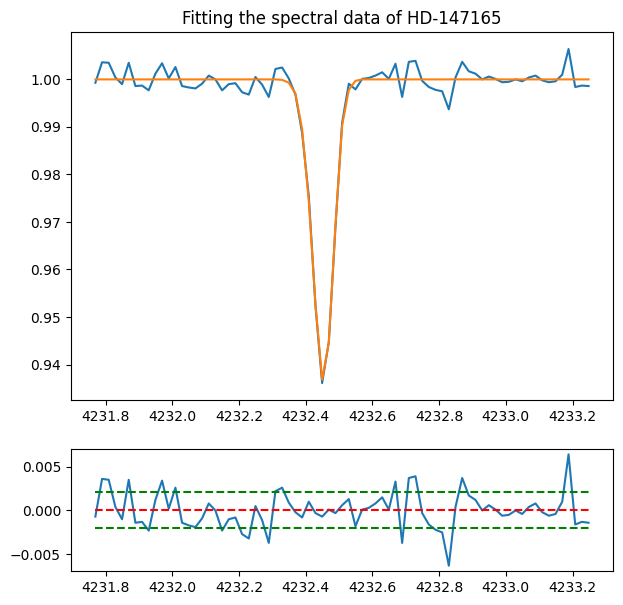

number of parameters: 6
Chi-squared: 97.58950617283983
Reduced Chi-squared: 1.4143406691715918
RMS error after fit: 0.0020532575743599925
std_dev from continuum using line-free regions: 0.0018
Log-likelihood: 356.2825
AIC:  -700.565005958462
BIC:  -686.6600772772442


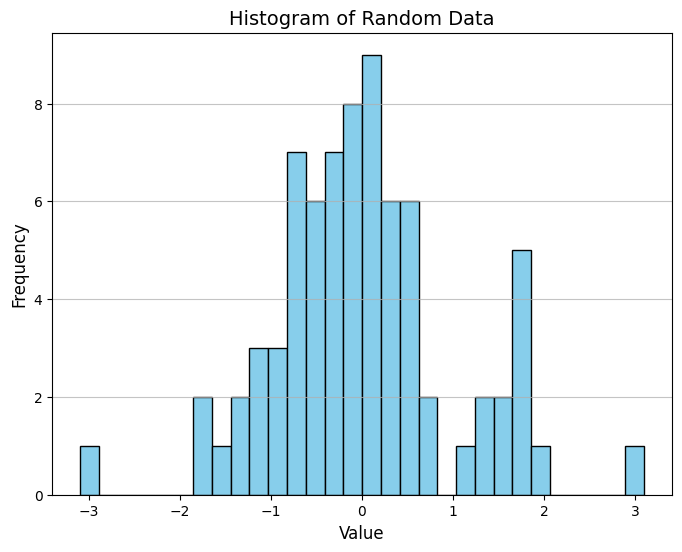

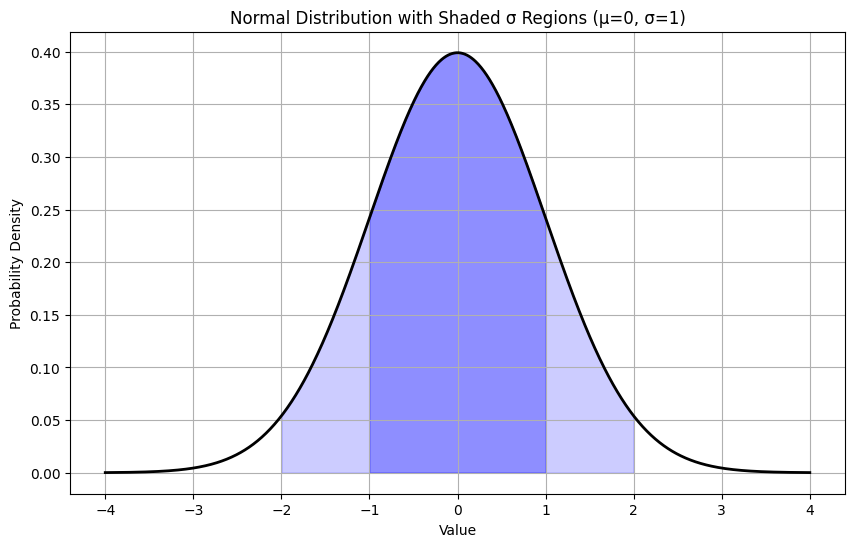

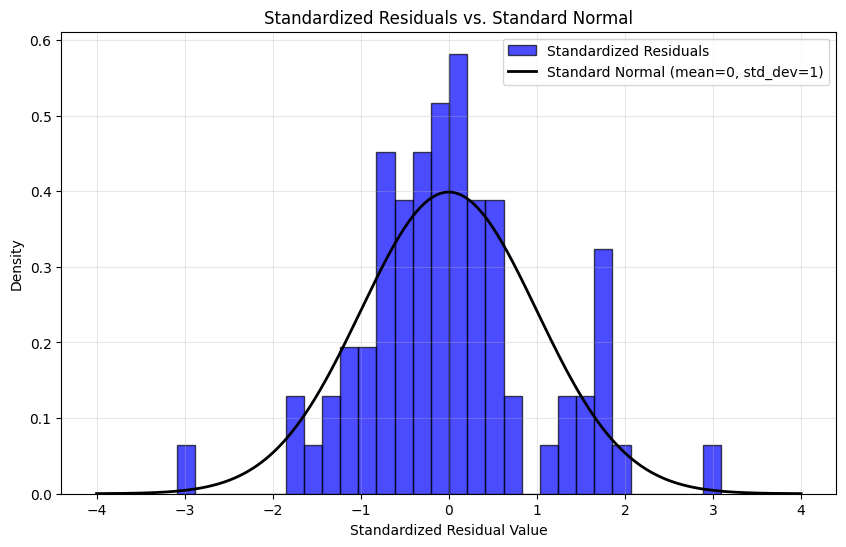

K-S statistic: 0.0940
P-value: 0.4916
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [2]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 147165_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-147165')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0018  # Assuming a standard deviation for the error
num_params = 6  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

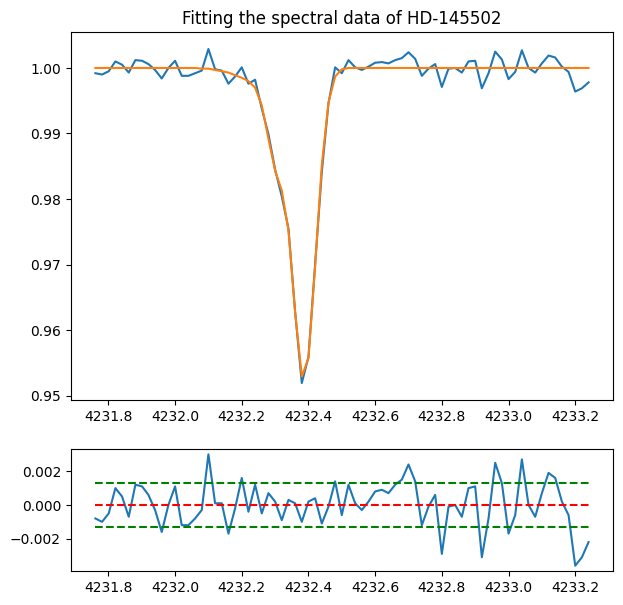

number of parameters: 9
Chi-squared: 128.1999999999991
Reduced Chi-squared: 1.9424242424242288
RMS error after fit: 0.0013074147518417104
std_dev from continuum using line-free regions: 0.001
Log-likelihood: 385.0613
AIC:  -752.1225118666206
BIC:  -731.2651188447937


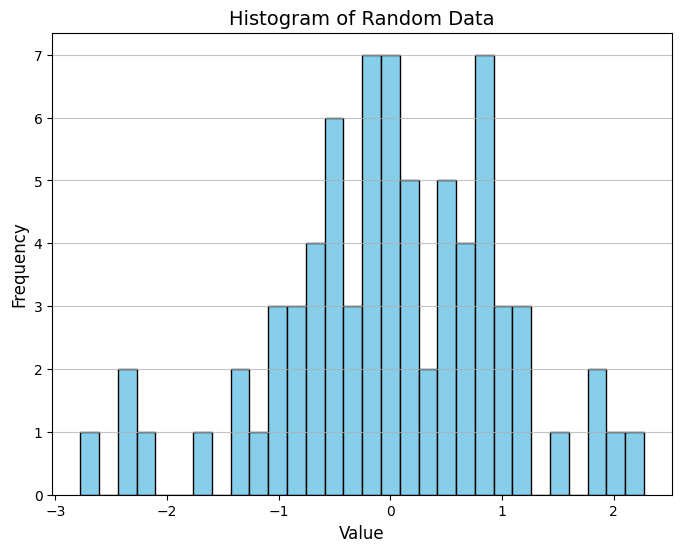

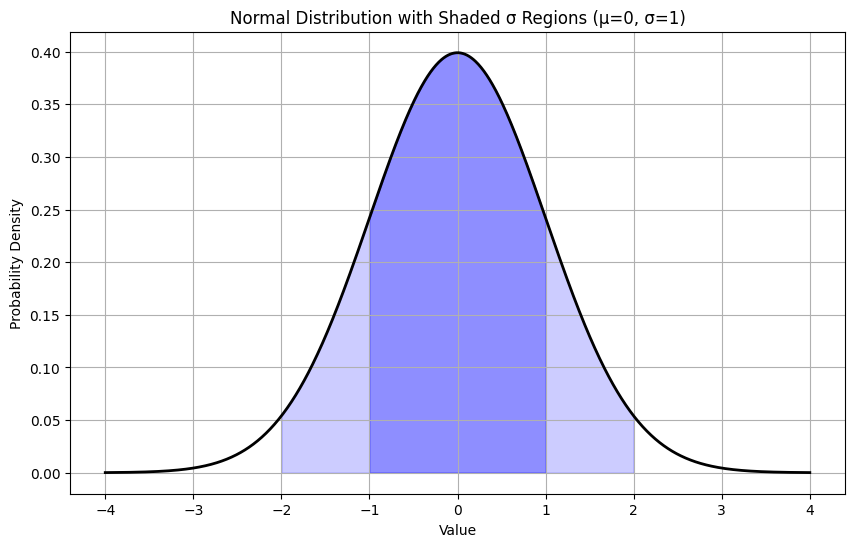

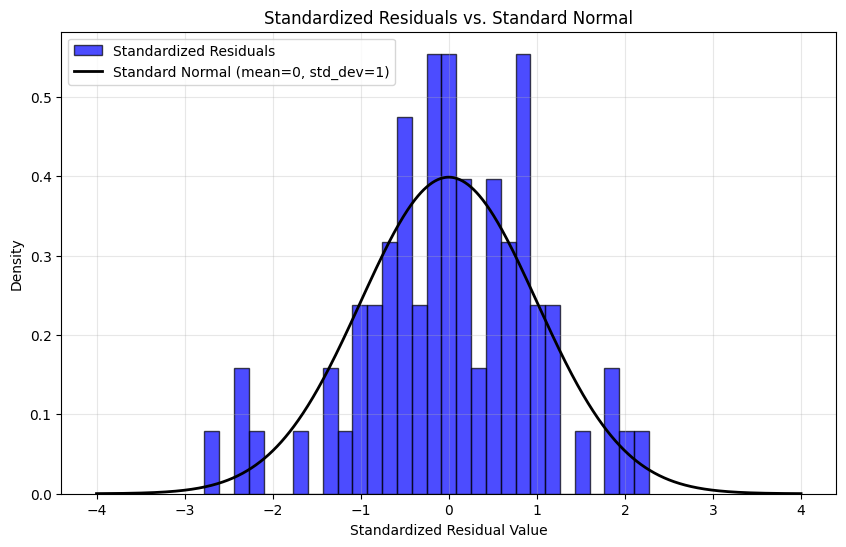

K-S statistic: 0.0668
P-value: 0.8689
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [3]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 145502_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-145502')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.001  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

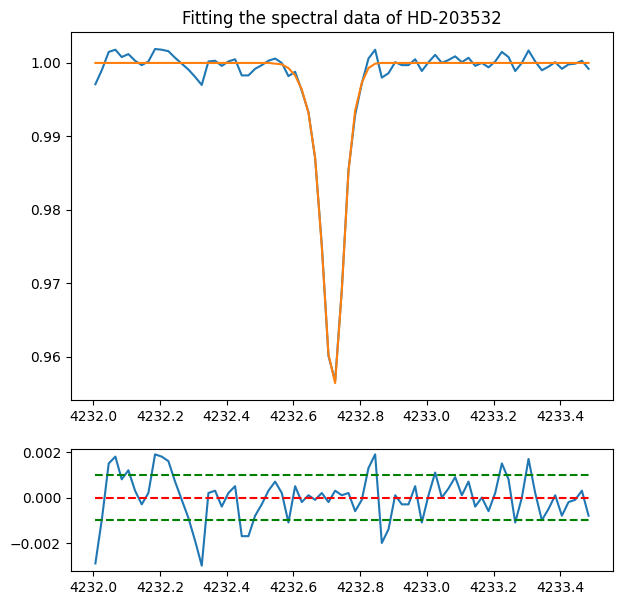

number of parameters: 9
Chi-squared: 62.83471074380205
Reduced Chi-squared: 0.9520410718757886
RMS error after fit: 0.0010068432516203007
std_dev from continuum using line-free regions: 0.0011
Log-likelihood: 410.5956
AIC:  -803.191274152169
BIC:  -782.3338811303422


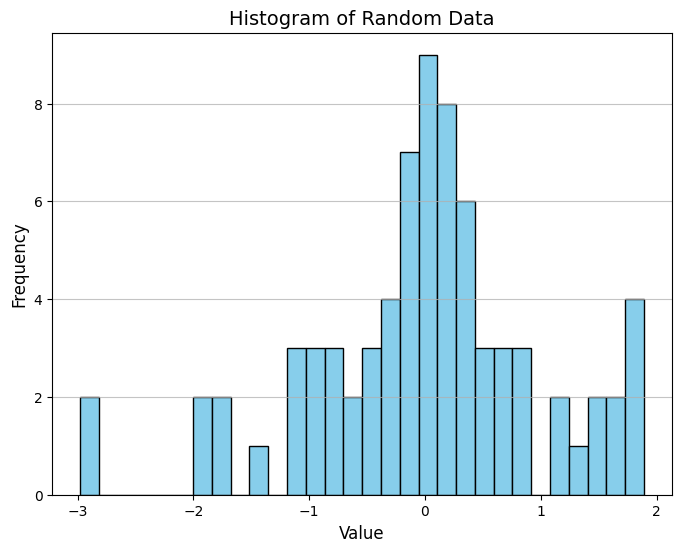

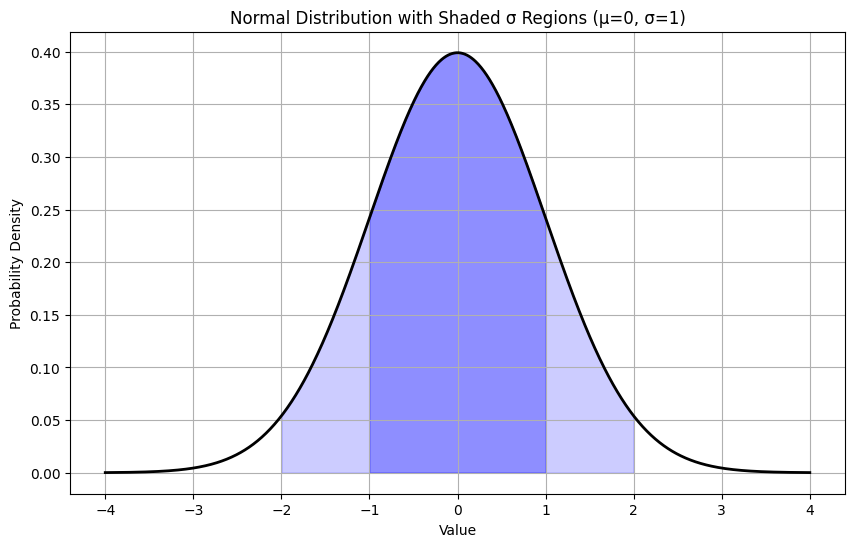

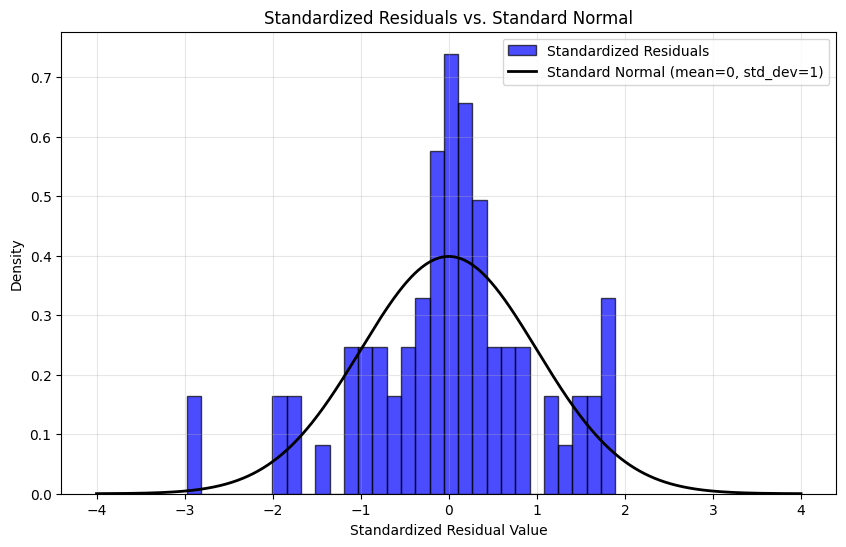

K-S statistic: 0.1044
P-value: 0.3621
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [17]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 203532_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-203532')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0011  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

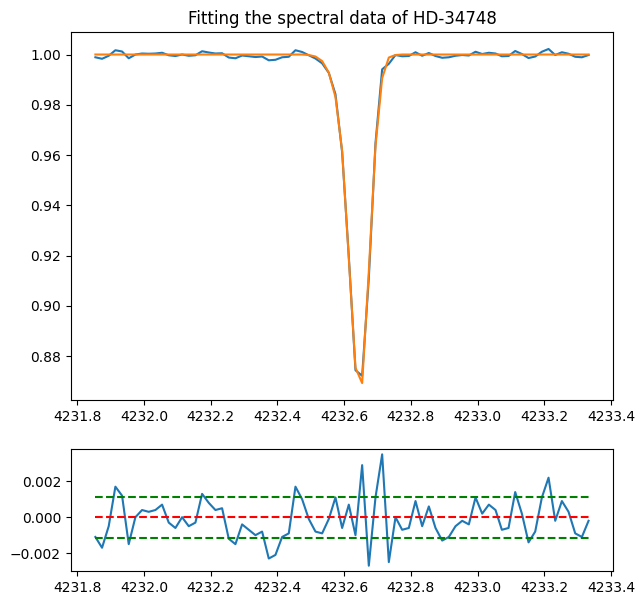

number of parameters: 7
Chi-squared: 99.26999999999866
Reduced Chi-squared: 1.459852941176451
RMS error after fit: 0.0011504781614615647
std_dev from continuum using line-free regions: 0.001
Log-likelihood: 399.5263
AIC:  -785.0525118666211
BIC:  -768.8300950718669


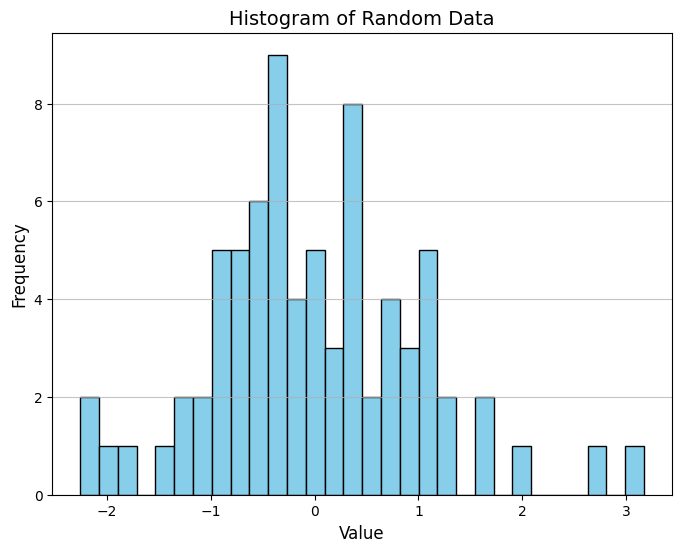

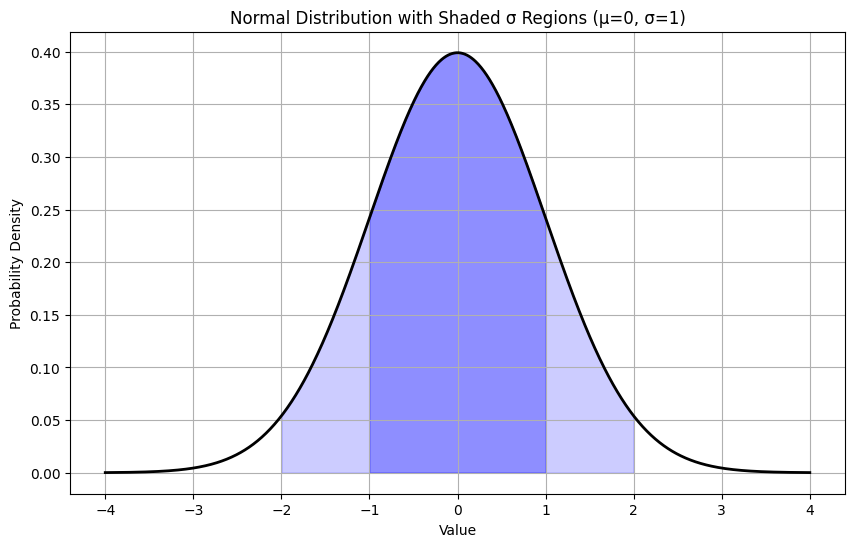

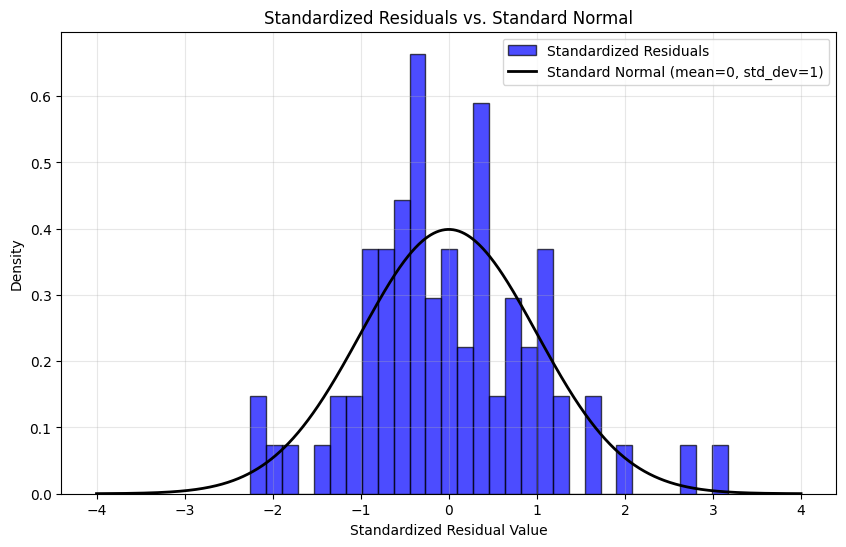

K-S statistic: 0.0822
P-value: 0.6614
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [27]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 34748_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-34748')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.001  # Assuming a standard deviation for the error
num_params = 7  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

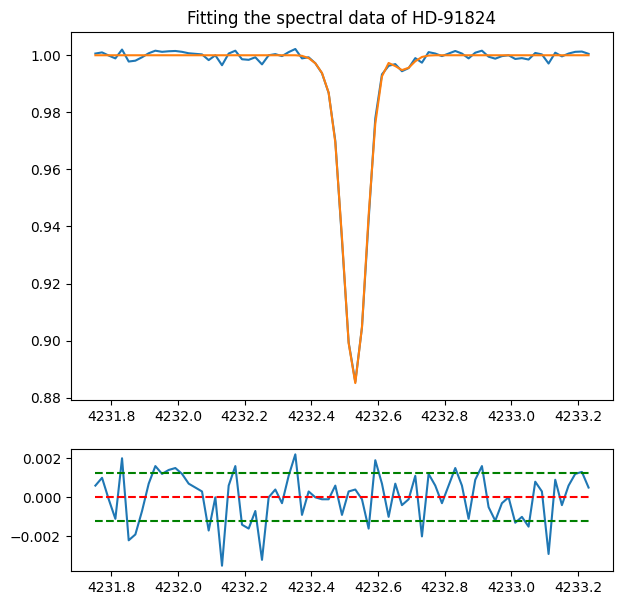

number of parameters: 9
Chi-squared: 92.55371900826411
Reduced Chi-squared: 1.4023290758827895
RMS error after fit: 0.0012219656296312078
std_dev from continuum using line-free regions: 0.0011
Log-likelihood: 395.7361
AIC:  -773.4722658877068
BIC:  -752.61487286588


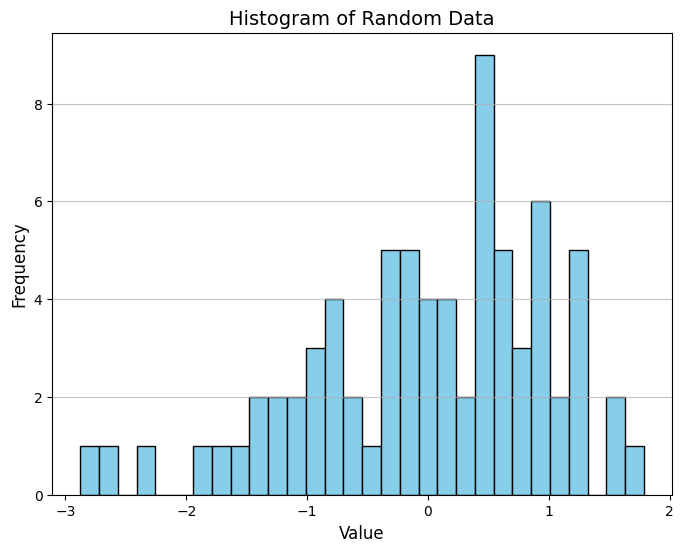

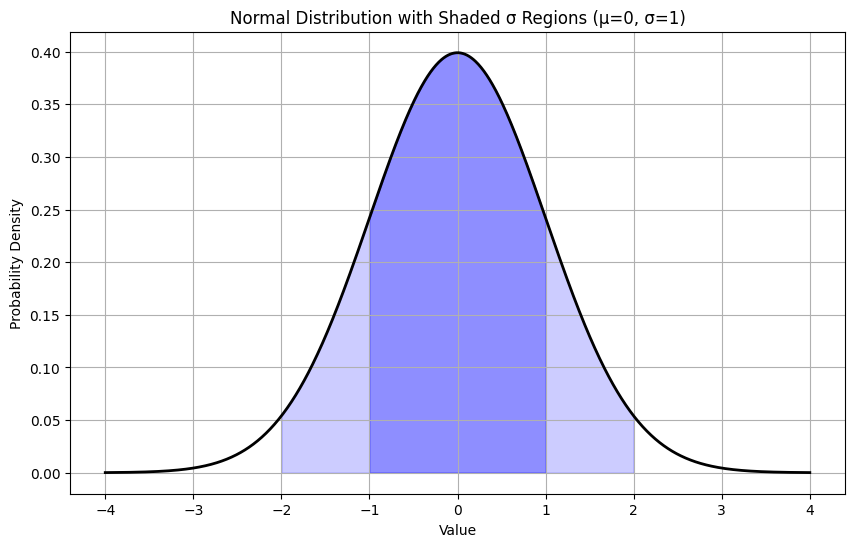

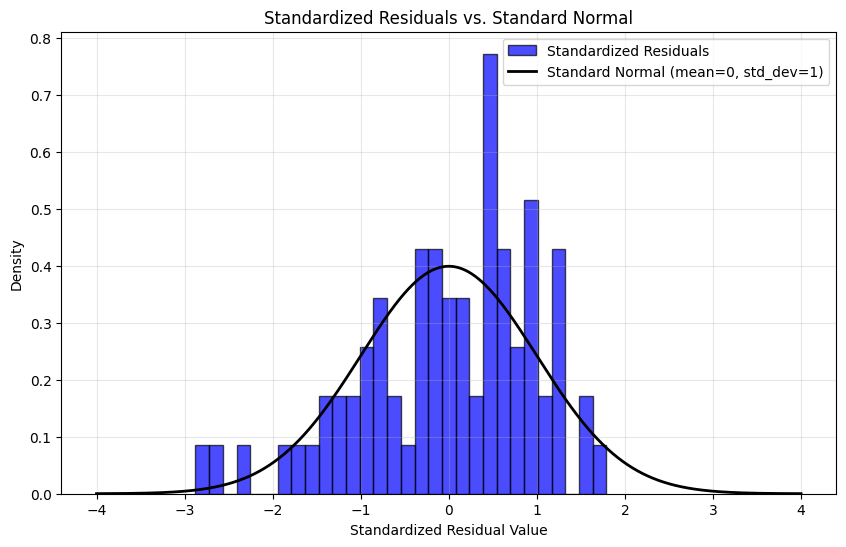

K-S statistic: 0.1123
P-value: 0.2790
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [33]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 91824_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-91824')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0011  # Assuming a standard deviation for the error
num_params = 9  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

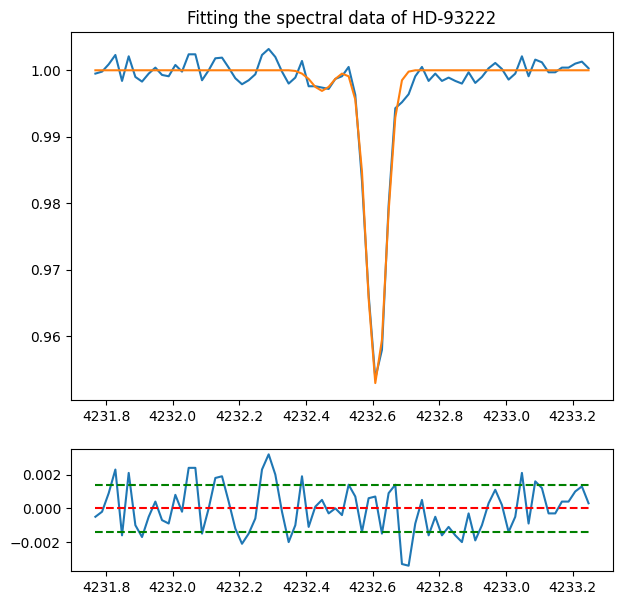

number of parameters: 6
Chi-squared: 121.04132231405035
Reduced Chi-squared: 1.7542220625224687
RMS error after fit: 0.0013974262055650784
std_dev from continuum using line-free regions: 0.0011
Log-likelihood: 381.4923
AIC:  -750.9846625819206
BIC:  -737.0797339007028


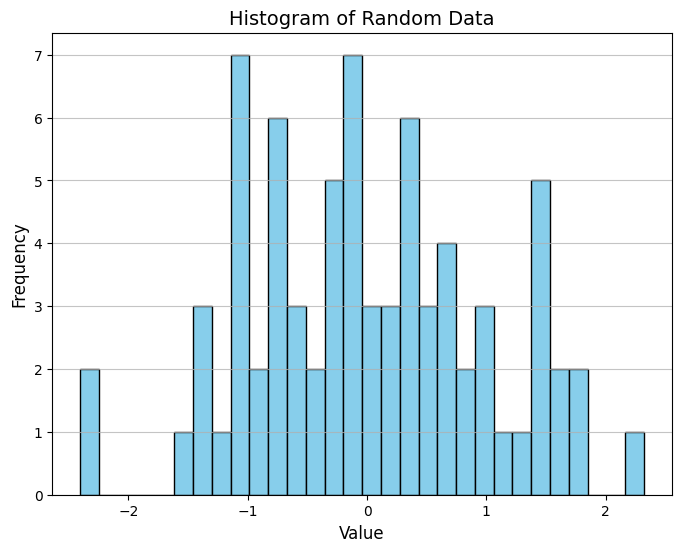

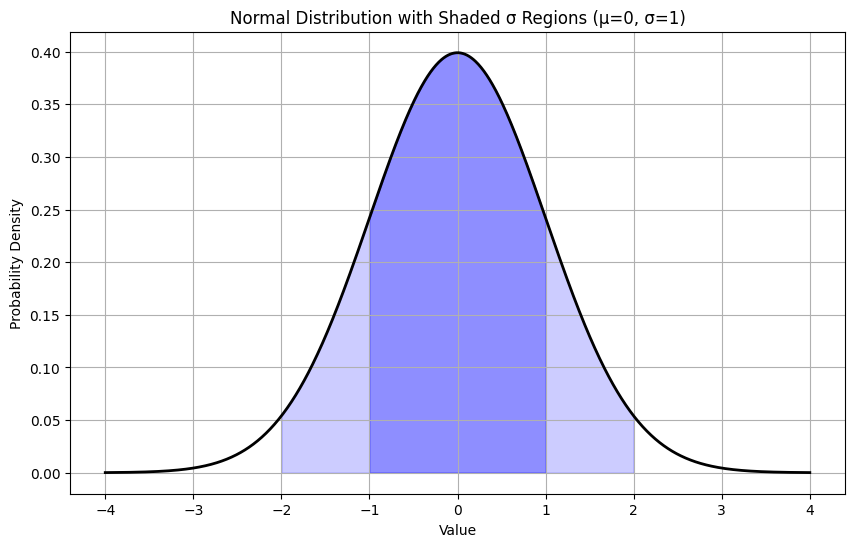

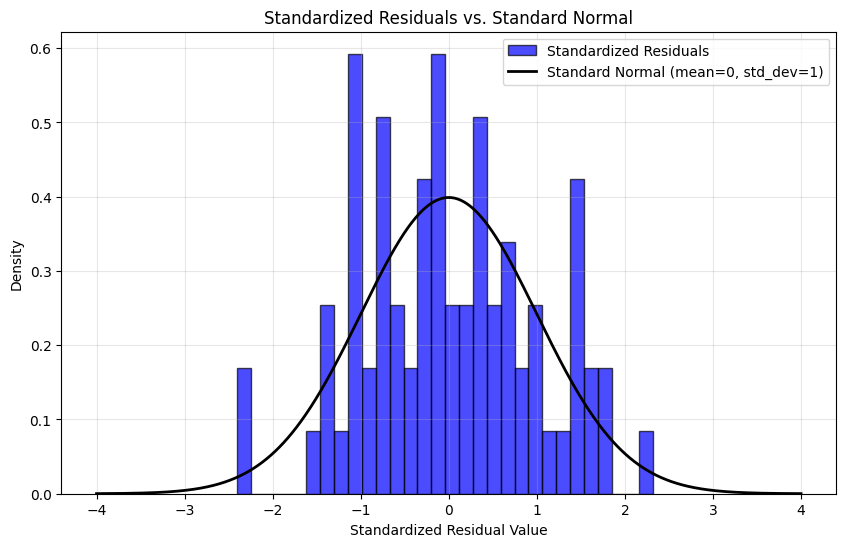

K-S statistic: 0.0648
P-value: 0.8904
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [45]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 93222_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-93222')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0011  # Assuming a standard deviation for the error
num_params = 6  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")

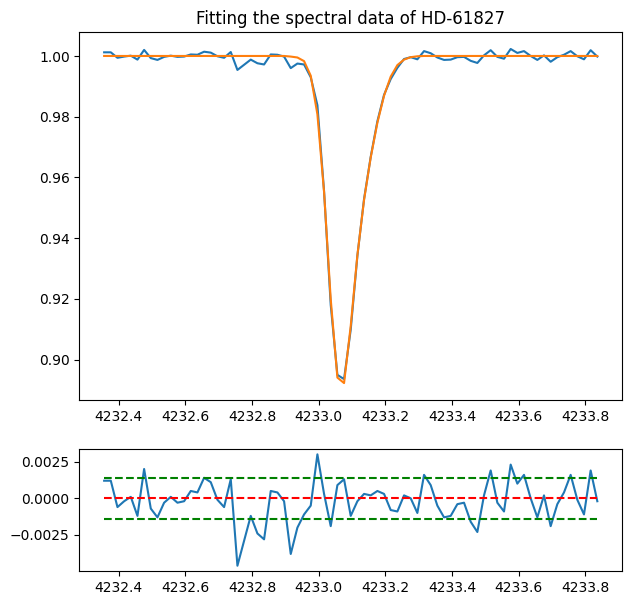

number of parameters: 8
Chi-squared: 84.44970414201246
Reduced Chi-squared: 1.2604433454031712
RMS error after fit: 0.0013794684966802783
std_dev from continuum using line-free regions: 0.0013
Log-likelihood: 387.2591
AIC:  -758.5181680544837
BIC:  -739.9782631461932


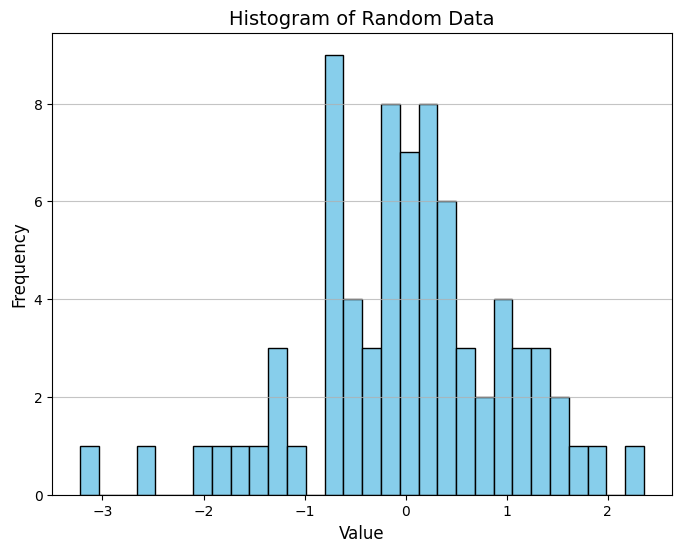

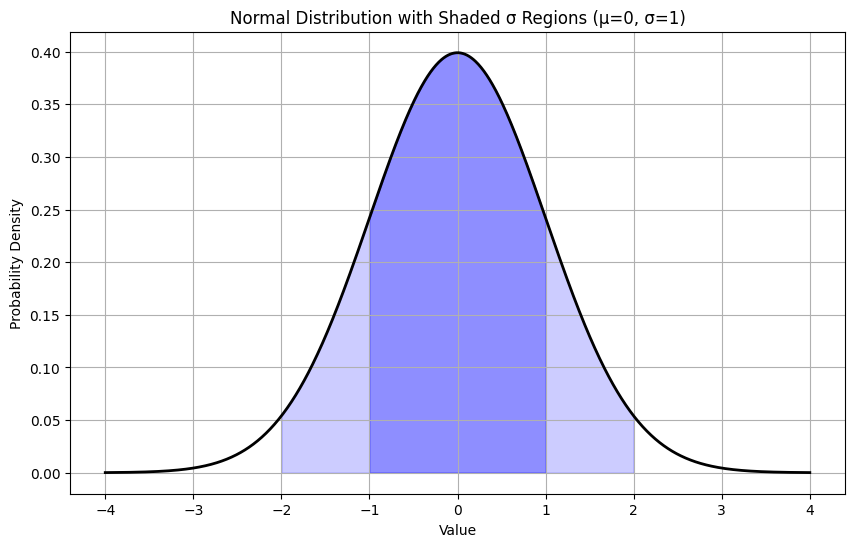

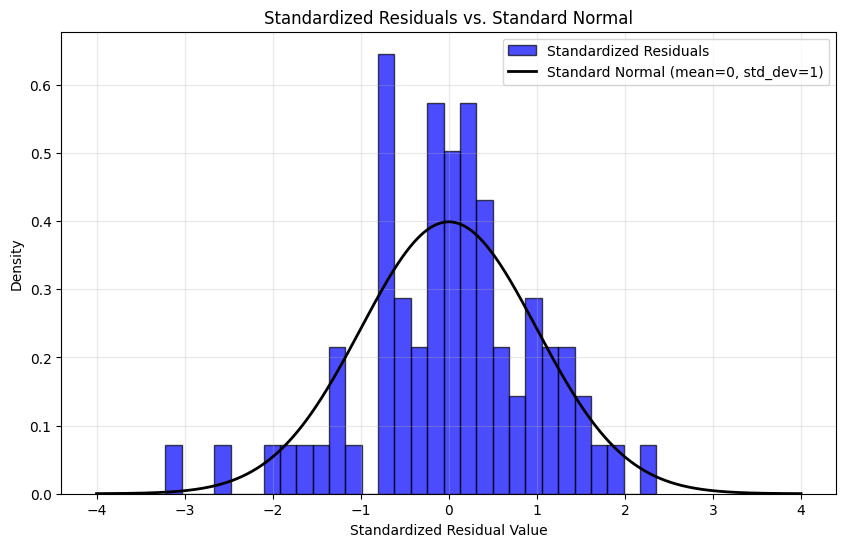

K-S statistic: 0.0793
P-value: 0.7031
p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed


In [50]:
wavelengths, fluxes, errors,fitted_fluxes = read_reg_file('HD 61827_plot.reg')

# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(7, 7))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Fitting the spectral data of HD-61827')
ax1.plot(wavelengths, fluxes, label='data')  
ax1.plot(wavelengths, fitted_fluxes, label='composite fit')




### chisquared calculator.

std_dev = 0.0013  # Assuming a standard deviation for the error
num_params = 8  # Number of parameters in the model (adjust as necessary)
chi_squared = np.sum(((fluxes - fitted_fluxes) / std_dev)**2)
rms_error = np.sqrt((np.sum((fluxes - fitted_fluxes)**2))/len(fluxes))





# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wavelengths, fluxes - fitted_fluxes)  
ax2.hlines(0, wavelengths.min(), wavelengths.max(), colors='red', linestyles='dashed')
ax2.hlines(rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
ax2.hlines(-rms_error, wavelengths.min(), wavelengths.max(), colors='green', linestyles='dashed')
# Show the plot
plt.show()


print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(fluxes) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")
# print(f"BIC: {chi_squared + num_params * np.log(len(fluxes))}")  # Bayesian Information Criterion
# print(f"AIC: {chi_squared + 2 * num_params}")  # Akaike Information Criterion

# Calculate log-likelihood
num_data_points = len(fluxes)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''


## Next is to check the residuals

Residuals = fluxes - fitted_fluxes
# Create the histogram
plt.figure(figsize=(8, 6))  # Set figure size
plt.hist((Residuals - np.mean(Residuals))/np.std(Residuals), bins=30, color='skyblue', edgecolor='black')
# Add labels and title
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Random Data', fontsize=14)
# Add grid lines
plt.grid(axis='y', alpha=0.75)
# Show the plot
plt.show()

from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
mu, sigma = 0, 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2)
# Shade 1σ region
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3)
# Shade 2σ region
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x <= mu+2*sigma)), color='blue', alpha=0.2)
plt.title(f'Normal Distribution with Shaded σ Regions (μ={mu}, σ={sigma})')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

# Standardize residuals
std_residuals = (Residuals - np.mean(Residuals)) / np.std(Residuals)
# Now plot histogram vs standard normal
plt.figure(figsize=(10, 6))
plt.hist(std_residuals, bins=30, density=True, 
        alpha=0.7, color='blue', edgecolor='black',
        label='Standardized Residuals')
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, 0, 1), 'k-', linewidth=2,
         label='Standard Normal (mean=0, std_dev=1)')
plt.xlabel('Standardized Residual Value')
plt.ylabel('Density')
plt.title('Standardized Residuals vs. Standard Normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




#'''''''''''''''''''''''''''''''''''''#############################################''''''''''''''''''''''''''''''''''''''''''



# Perform K-S test against standard normal distribution

import numpy as np
from scipy import stats
ks_statistic, p_value = stats.kstest(std_residuals, 'norm')
print(f"K-S statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
# Interpret the results
alpha = 0.05  # significance level
if p_value > alpha:
    print("p>0.05 hence Fail to reject null hypothesis - residuals appear normally distributed")
else:
    print("p<0.05 hence Reject null hypothesis - residuals do not appear normally distributed")